# Customer Churn Prediction using Logistic Regression

In [28]:
#Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [29]:
#Loading Dataset

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.head())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [30]:
#Exploring the Dataset

print("Shape of Dataset:")
print(df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)
print("\nStatistical Summary:")
print(df.describe())
print("\nFirst 5 Rows:")
print(df.head())
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

Shape of Dataset:
(7043, 21)

Column Names:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Ch

In [31]:
#Check the Missing Values

df.isnull().sum()



,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [32]:
print("TotalCharges Data Type:")
print(df['TotalCharges'].dtype)
print("\nBlank TotalCharges:")
print((df['TotalCharges'].str.strip() == '').sum())





TotalCharges Data Type:
object

Blank TotalCharges:
11


In [33]:
#In Total Charge has 11 Blanks.
#Lets Remove 11 Blanks

df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df = df.dropna(subset=['TotalCharges'])
print("Missing TotalCharges:")
print(df['TotalCharges'].isnull().sum())
print("\nTotalCharges Data Type:")
print(df['TotalCharges'].dtype)
print("\nDataset Shape:")
print(df.shape)

Missing TotalCharges:
0

TotalCharges Data Type:
float64

Dataset Shape:
(7032, 21)


In [34]:
#Selecting X and y

df['Churn'] = df['Churn'].map({ 'No' : 0, 'Yes' : 1})
X = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
y = df['Churn']
print("X:")
print(X.head())
print("\ny:")
print(y.head())
print("\nTarget Distribution:")
print(y.value_counts())

X:
   tenure  MonthlyCharges  TotalCharges
0       1           29.85         29.85
1      34           56.95       1889.50
2       2           53.85        108.15
3      45           42.30       1840.75
4       2           70.70        151.65

y:
0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

Target Distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [35]:
#Using tain,test,split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.2, random_state = 42)
print("X_Train Shape:", X_train.shape)
print("X_Test Shape:", X_test.shape)
print("y_Train Shape:", y_train.shape)
print("y_Test Shape:", y_test.shape)

X_Train Shape: (5625, 3)
X_Test Shape: (1407, 3)
y_Train Shape: (5625,)
y_Test Shape: (1407,)


In [36]:
#Introducing Standard Scaler

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)
print("Scaled X_train:")
print(X_train_scaled[:5])

Scaled X_train:
[[ 0.43467403 -0.51862031 -0.08790784]
 [-1.19565249 -0.3744434  -0.92128463]
 [ 0.92377199  0.43261589  0.96378055]
 [ 0.51619036 -0.33301325  0.12291993]
 [ 0.92377199  1.19990224  1.40108812]]


In [37]:
#Implementing Logistic Regression Model

model = LogisticRegression()
model.fit(X_train_scaled, y_train)


LogisticRegression()

In [38]:
#Learning Weights & Intercepts

print("Weights (Coefficients):")
print(model.coef_)
print("\nIntercept:")
print(model.intercept_)

Weights (Coefficients):
[[-1.66836137  0.92573724  0.34257378]]

Intercept:
[-1.49626761]


In [39]:
#Predicting Churn Probabilities

y_probability = model.predict_proba(X_test_scaled)
print("Predicted Churn Probabilities:")
print(y_probability)

Predicted Churn Probabilities:
[[0.99167786 0.00832214]
 [0.88996615 0.11003385]
 [0.30319265 0.69680735]
 ...
 [0.80845777 0.19154223]
 [0.50670074 0.49329926]
 [0.99581286 0.00418714]]


In [40]:
#Converting Probability to churn/no churn

prob_churn = model.predict_proba(X_test_scaled)[:, 1]
threshold = 0.5
y_pred = (prob_churn >= threshold).astype(int)
print("Predicted Churn Classes:")
print(y_pred[:10])
print("\nActual Churn Classes:")
print(y_test.head(10).values)

Predicted Churn Classes:
[0 0 1 0 0 0 0 1 0 0]

Actual Churn Classes:
[0 0 1 0 0 0 0 0 0 0]


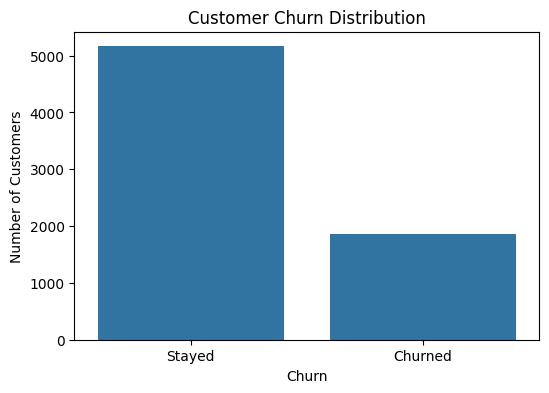

In [41]:
#Churn Distribution Graph

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.show()

In [42]:
#Confusion MAtrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[937  96]
 [215 159]]


In [43]:
#Accuracy Score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

Accuracy Score: 0.7789623312011372


In [44]:
#Precision

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.6235294117647059


In [45]:
#Recall

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.42513368983957217


In [46]:
#F1 Score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.505564387917329


In [47]:
#ROC-AUC

roc_auc = roc_auc_score(y_test, prob_churn)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.7997887881721377
